# **Ask**

Three main questions of the project:
1) How many bacteria species are in the initial dataset.
2) What is the localization of the harmful bacteria species.
3) Which of the harmful bacteria are on the WHO priority pathogens list.
4) What is the localization of the WHO-listed bacteria species.

# **Prepare**

The 'Bacteria dataset' is a public dataset made available through Kanchana Karunarathna. 
This dataset provides an overview of bacterial species, highlighting their scientific classification, natural habitats, and potential impacts on human health. The 'Bacteria dataset' can be used for studies in microbiology, public health, and environmental science. This dataset consists of one csv file. The file has duplicated values and no empty rows.


**Loading libraries:**

In [1]:
library(tidyverse)
library(janitor)
library(RColorBrewer)
library(wordcloud2)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     


── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors



Attaching package: ‘janitor’




The following objects are masked from ‘package:stats’:

    chisq.test, fisher.test




**Loading and cleaning files:**

In [2]:
bacteria_list = read_csv('/kaggle/input/bacteria-dataset/bacteria_list_200.csv')

bacteria_list1 <- clean_names(bacteria_list)       # Provide only characters, numbers and underscores in the name
glimpse(bacteria_list1)                            # 199 rows

Rows: 199 Columns: 4


── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (4): Name, Family, Where Found, Harmful to Humans



ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Rows: 199
Columns: 4
$ name              <chr> "Escherichia coli", "Staphylococcus aureus", "Lactob…
$ family            <chr> "Enterobacteriaceae", "Staphylococcaceae", "Lactobac…
$ where_found       <chr> "Intestinal tract", "Skin, nasal passages", "Human m…
$ harmful_to_humans <chr> "Yes", "Yes", "No", "No", "Yes", "Yes", "Yes", "Yes"…


In [3]:
# Removing duplicates
bacteria <- unique(bacteria_list1)
glimpse(bacteria)                                  # 195 unique rows, 4 rows were removed

Rows: 195
Columns: 4
$ name              <chr> "Escherichia coli", "Staphylococcus aureus", "Lactob…
$ family            <chr> "Enterobacteriaceae", "Staphylococcaceae", "Lactobac…
$ where_found       <chr> "Intestinal tract", "Skin, nasal passages", "Human m…
$ harmful_to_humans <chr> "Yes", "Yes", "No", "No", "Yes", "Yes", "Yes", "Yes"…


In [4]:
# There are no empty values in the data frame
empty_value <- which(is.na(bacteria))
empty_value

integer(0)

# Process, Analyze, Share

## Harmful bacteria dataset

**Checking how many bacteria are harmful to humans:**

In [5]:
harmful <- bacteria %>% group_by(harmful_to_humans) %>% 
  summarise(number = n()) %>% 
  mutate(percent = number/sum(number)*100)
harmful # 47,7% of listed bacterial species are harmful to humans

harmful_to_humans,number,percent
<chr>,<int>,<dbl>
No,102,52.30769
Yes,93,47.69231


Pie chart of the number of harmful/harmless bacterial species in 'bacteria' data frame:

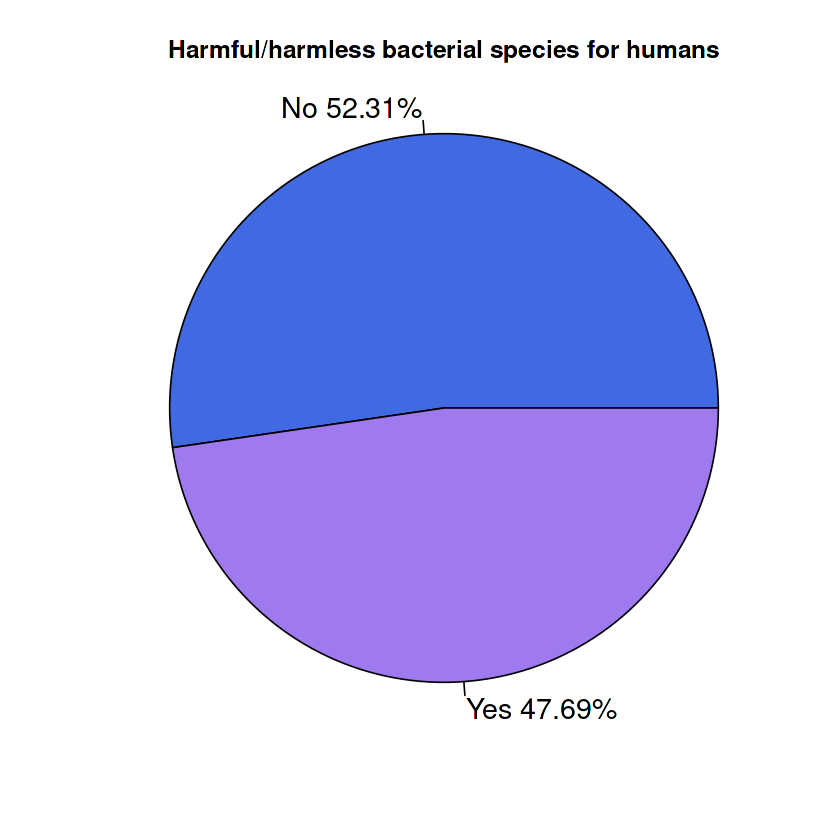

In [6]:
pct <- round(harmful$percent, 2)
lbls <- paste(paste(harmful$harmful_to_humans, pct), "%", sep="")
pie(harmful$percent, labels = lbls, col = c("royalblue", "mediumpurple2"),radius = 2,cex = 1.4,
    main = "Harmful/harmless bacterial species for humans")

**Analyzing the habitats of the harmful bacteria species.**

Creation the function that split comma-separated values of the 'where_found' column into multiple rows, remove whitespaces at the beginning of the row and convert to title case:

In [7]:
location_convertion <- function(df) {
  separate_rows(df, where_found, sep = ",", convert = TRUE) %>% 
    mutate_all(function(x)trimws(x)) %>% 
    mutate(where_found = paste0(toupper(substring(where_found, 1, 1)), substring(where_found, 2)))
}

df <- bacteria
location <- location_convertion(df)
glimpse(location)

Rows: 267
Columns: 4
$ name              <chr> "Escherichia coli", "Staphylococcus aureus", "Staphy…
$ family            <chr> "Enterobacteriaceae", "Staphylococcaceae", "Staphylo…
$ where_found       <chr> "Intestinal tract", "Skin", "Nasal passages", "Human…
$ harmful_to_humans <chr> "Yes", "Yes", "Yes", "No", "No", "Yes", "Yes", "Yes"…


In [8]:
# Group by family and location
location1 <- location %>% 
  group_by(family, where_found, harmful_to_humans) %>% 
  summarise(n()) %>% 
  filter(harmful_to_humans == "Yes")

head(location1)

`summarise()` has grouped output by 'family', 'where_found'. You can override
using the `.groups` argument.


family,where_found,harmful_to_humans,n()
<chr>,<chr>,<chr>,<int>
Aerococcaceae,Human skin,Yes,1
Aerococcaceae,Wounds,Yes,1
Aeromonadaceae,Fish,Yes,1
Aeromonadaceae,Freshwater,Yes,1
Alcaligenaceae,Human urogenital tract,Yes,1
Alcaligenaceae,Respiratory tract,Yes,1


The chart that shows the locations of harmful bacterial species:

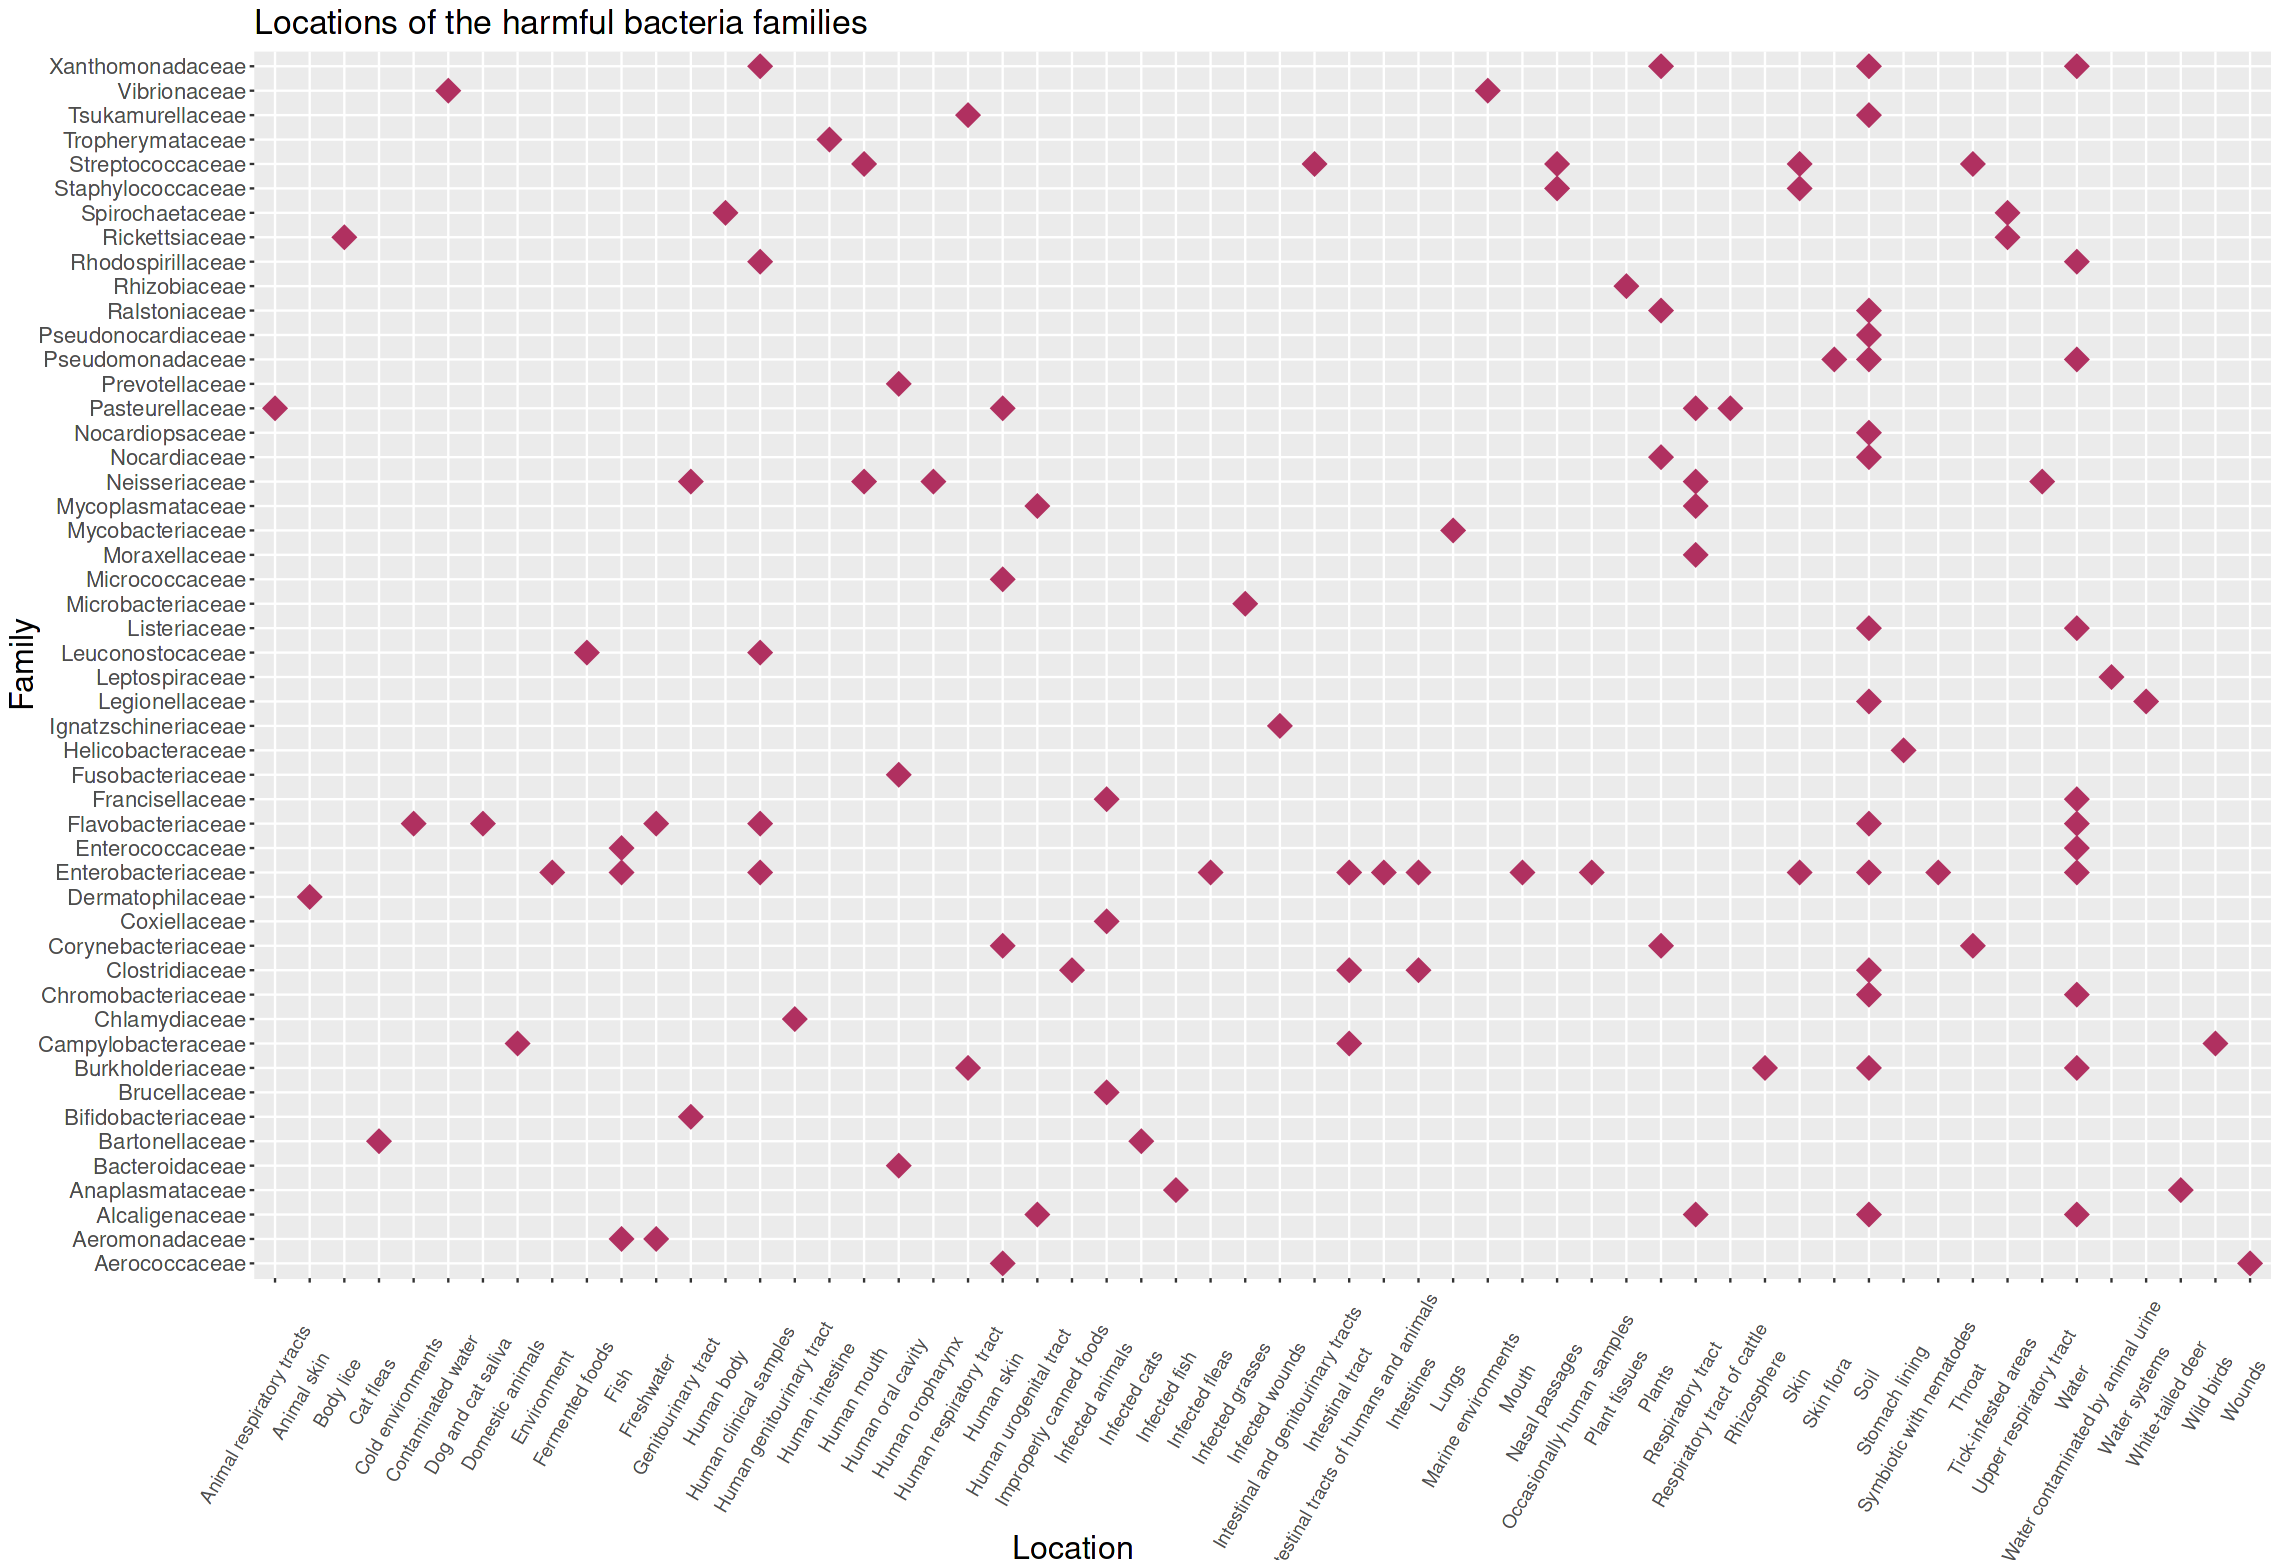

In [9]:
options(repr.plot.width = 19, repr.plot.height = 13) 

p_location <- 
  ggplot(data = location1) +
  geom_point(mapping = aes(x = where_found, y = family), color = "maroon", shape = 18, size = 7)+
  labs(title="Locations of the harmful bacteria families",
       x = "Location",
       y = "Family") 

p_location + theme(plot.title = element_text(size = 20),
                   axis.text.x = element_text(hjust = 0.7, size = 11, vjust=0.5, margin=margin(-25,0,-2,0), angle = 60),
                   axis.text.y = element_text(size=13),
                   axis.title.x = element_text(vjust = -1.0, hjust = 0.4, size = 19),
                   axis.title.y =element_text(size = 19))

Reviewing the most  common locations of harmful to human bacteria and sorting the data by 'where_found' column:

In [10]:
location_com <- location %>% 
  group_by(where_found, harmful_to_humans) %>% 
  summarise(n = n()) %>% 
  filter(harmful_to_humans == "Yes") %>% 
  arrange(desc(n)) %>% 
  head(n = 8)

location_com

location_com1 <- location_com %>%
  mutate(where_found = sort(where_found))

glimpse(location_com1)

`summarise()` has grouped output by 'where_found'. You can override using the
`.groups` argument.


where_found,harmful_to_humans,n
<chr>,<chr>,<int>
Soil,Yes,18
Water,Yes,12
Intestinal tract,Yes,6
Human clinical samples,Yes,5
Plants,Yes,5
Respiratory tract,Yes,5
Human skin,Yes,4
Infected animals,Yes,4


Rows: 8
Columns: 3
Groups: where_found [8]
$ where_found       <chr> "Soil", "Water", "Intestinal tract", "Human clinical…
$ harmful_to_humans <chr> "Yes", "Yes", "Yes", "Yes", "Yes", "Yes", "Yes", "Ye…
$ n                 <int> 18, 12, 6, 5, 5, 5, 4, 4


The most  common locations of harmful to human bacteria are soil, water, and the intestinal tract:

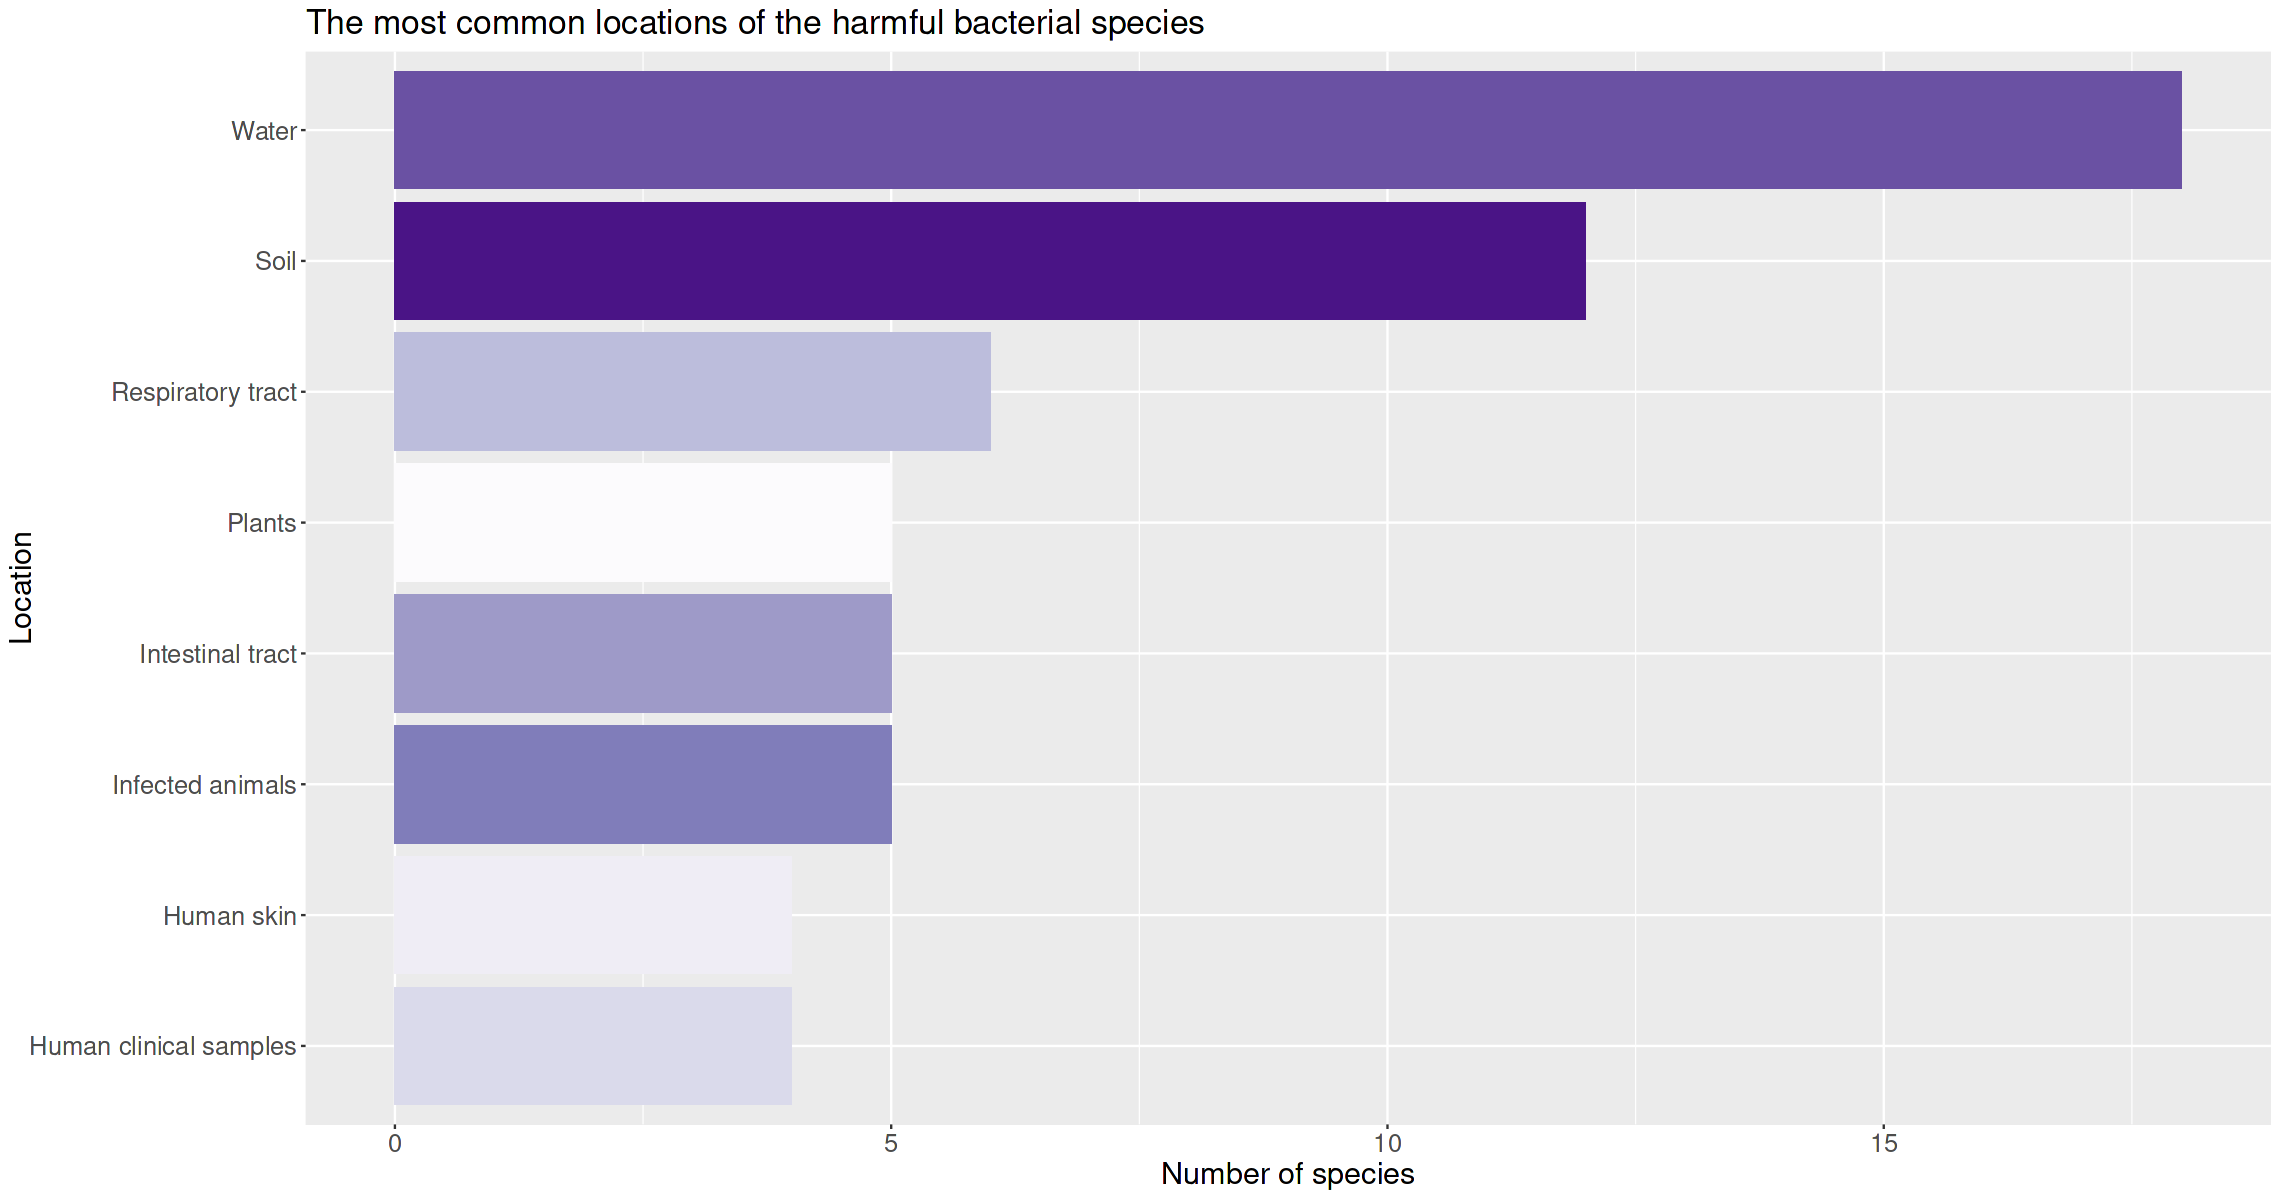

In [11]:
options(repr.plot.width = 19, repr.plot.height = 10) 

p_location_com <- 
  ggplot(data = location_com1) +
  geom_bar(mapping = aes(x = n, y = sort(where_found, decreasing = TRUE), fill = where_found),width = 0.9,
           stat = "identity", show.legend = FALSE) +
  labs(
    title = "The most common locations of the harmful bacterial species",
    x = "Number of species",
    y = "Location"
  ) +
  scale_fill_brewer(palette = "Purples") +
  theme(plot.title = element_text(size = 20),
        axis.text.x = element_text(size = 15), axis.title.x =element_text(size = 18),
        axis.text.y = element_text(size = 15), axis.title.y =element_text(size = 18))
p_location_com

## WHO pathogens list

**WHO**  published the list of antibiotic-resistant "priority pathogens" – a catalogue of bacteria that pose the greatest threat to human health.

Link: https://www.who.int/news/item/27-02-2017-who-publishes-list-of-bacteria-for-which-new-antibiotics-are-urgently-needed

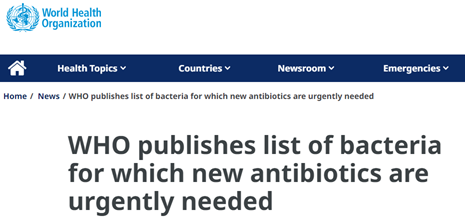

Species of bacteria on the WHO list:

In [12]:
who_names <- 
  as.list(c("Acinetobacter baumannii", "Pseudomonas aeruginosa", "Enterococcus faecium",
            "Staphylococcus aureus", "Helicobacter pylori", "Neisseria gonorrhoeae", 
            "Streptococcus pneumoniae", "Haemophilus influenzae"))
who_names                                # 8 pathogen names on the WHO list
class(who_names)

[[1]]
[1] "Acinetobacter baumannii"

[[2]]
[1] "Pseudomonas aeruginosa"

[[3]]
[1] "Enterococcus faecium"

[[4]]
[1] "Staphylococcus aureus"

[[5]]
[1] "Helicobacter pylori"

[[6]]
[1] "Neisseria gonorrhoeae"

[[7]]
[1] "Streptococcus pneumoniae"

[[8]]
[1] "Haemophilus influenzae"

[1] "list"

Bacteria families on the WHO list:

In [13]:
who_families <- as.list(c("Enterobacteriaceae", "Campylobacter", "Salmonellae", "Shigella"))
who_families                             # 4 pathogen family names on the WHO list
class(who_families)

[[1]]
[1] "Enterobacteriaceae"

[[2]]
[1] "Campylobacter"

[[3]]
[1] "Salmonellae"

[[4]]
[1] "Shigella"

[1] "list"

List of the species and families of bacteria from the 'bacteria' data frame:

In [14]:
bac_names <- as.list(bacteria$name)
head(bac_names)                                        # 195 names
class(bac_names)

bac_families <- as.list(bacteria$family)
head(bac_families)                                   # 195 family names
bac_families <- unique(bac_families)          # 92 unique family names
class(bac_families)

[[1]]
[1] "Escherichia coli"

[[2]]
[1] "Staphylococcus aureus"

[[3]]
[1] "Lactobacillus acidophilus"

[[4]]
[1] "Bacillus subtilis"

[[5]]
[1] "Clostridium botulinum"

[[6]]
[1] "Streptococcus pneumoniae"

[1] "list"

[[1]]
[1] "Enterobacteriaceae"

[[2]]
[1] "Staphylococcaceae"

[[3]]
[1] "Lactobacillaceae"

[[4]]
[1] "Bacillaceae"

[[5]]
[1] "Clostridiaceae"

[[6]]
[1] "Streptococcaceae"

[1] "list"

Function that lists all the WHO pathogens that are in the bacteria data frame:

In [15]:
counter <- function(who, bac) {
  matches <- bac[bac %in% who]                          #  matches
  cat(length(matches), "matches found.\n")              # print the number of matches
  return(matches)
}

Matches in bacterial species names:

In [16]:
who <- who_names
bac <- bac_names

bac_matches <- counter(who_names, bac_names) 
bac_matches
class(bac_matches)

6 matches found.


[[1]]
[1] "Staphylococcus aureus"

[[2]]
[1] "Streptococcus pneumoniae"

[[3]]
[1] "Pseudomonas aeruginosa"

[[4]]
[1] "Helicobacter pylori"

[[5]]
[1] "Neisseria gonorrhoeae"

[[6]]
[1] "Haemophilus influenzae"

[1] "list"

In [17]:
# Filter the bacteria data for matches to data frame
bac_matches_bacteria <- 
  bacteria[bacteria$name %in% bac_matches, ]
bac_matches_bacteria

name,family,where_found,harmful_to_humans
<chr>,<chr>,<chr>,<chr>
Staphylococcus aureus,Staphylococcaceae,"Skin, nasal passages",Yes
Streptococcus pneumoniae,Streptococcaceae,"Throat, nasal passages",Yes
Pseudomonas aeruginosa,Pseudomonadaceae,"Soil, water, skin flora",Yes
Helicobacter pylori,Helicobacteraceae,Stomach lining,Yes
Neisseria gonorrhoeae,Neisseriaceae,Genitourinary tract,Yes
Haemophilus influenzae,Pasteurellaceae,Respiratory tract,Yes


Matches in bacteria families

In [18]:
who <- who_families
bac <- bac_families

family_matches <- counter(who, bac)
family_matches
class(family_matches)

1 matches found.


[[1]]
[1] "Enterobacteriaceae"

[1] "list"

In [19]:
# Filtering the bacteria data for matches

bac_matches_families <- 
  bacteria %>% 
  filter(family %in% family_matches)
head(bac_matches_families)                                # 21 matches

name,family,where_found,harmful_to_humans
<chr>,<chr>,<chr>,<chr>
Escherichia coli,Enterobacteriaceae,Intestinal tract,Yes
Salmonella enterica,Enterobacteriaceae,Intestinal tract,Yes
Shigella dysenteriae,Enterobacteriaceae,Intestinal tract,Yes
Klebsiella pneumoniae,Enterobacteriaceae,"Mouth, skin, intestines",Yes
Serratia marcescens,Enterobacteriaceae,"Soil, water, intestines",No
Proteus mirabilis,Enterobacteriaceae,Intestinal tract,No


In [20]:
# List of all the bacteria in 'bacteria' data frame that match the WHO pathogen list

who_bacteria_matches <- full_join(bac_matches_bacteria, bac_matches_families)
head(who_bacteria_matches)                                  # all together 27 matches

Joining with `by = join_by(name, family, where_found, harmful_to_humans)`


name,family,where_found,harmful_to_humans
<chr>,<chr>,<chr>,<chr>
Staphylococcus aureus,Staphylococcaceae,"Skin, nasal passages",Yes
Streptococcus pneumoniae,Streptococcaceae,"Throat, nasal passages",Yes
Pseudomonas aeruginosa,Pseudomonadaceae,"Soil, water, skin flora",Yes
Helicobacter pylori,Helicobacteraceae,Stomach lining,Yes
Neisseria gonorrhoeae,Neisseriaceae,Genitourinary tract,Yes
Haemophilus influenzae,Pasteurellaceae,Respiratory tract,Yes


Adding a new column with the information on whether the bacteria are on the WHO list

In [21]:
bacteria1 <- bacteria %>%
  mutate(who_list = case_when(
    name %in% bac_matches ~ "On",
    family %in% family_matches ~ "On",
    TRUE ~ "Off"                                  
  ))
glimpse(bacteria1)

Rows: 195
Columns: 5
$ name              <chr> "Escherichia coli", "Staphylococcus aureus", "Lactob…
$ family            <chr> "Enterobacteriaceae", "Staphylococcaceae", "Lactobac…
$ where_found       <chr> "Intestinal tract", "Skin, nasal passages", "Human m…
$ harmful_to_humans <chr> "Yes", "Yes", "No", "No", "Yes", "Yes", "Yes", "Yes"…
$ who_list          <chr> "On", "On", "Off", "Off", "Off", "On", "On", "Off", …


Checking out how many bacteria are on the WHO list

13,8% of all the bacteria at the 'bacteria' data frame are in the WHO list:

In [22]:
who_bacteria_matches_harmful <- 
  bacteria1 %>% 
  group_by(who_list) %>% 
  summarise(number = n()) %>% 
  mutate(percent = number/sum(number)*100)
who_bacteria_matches_harmful

who_list,number,percent
<chr>,<int>,<dbl>
Off,168,86.15385
On,27,13.84615


Pie chart of the number of species and families that are on the WHO list

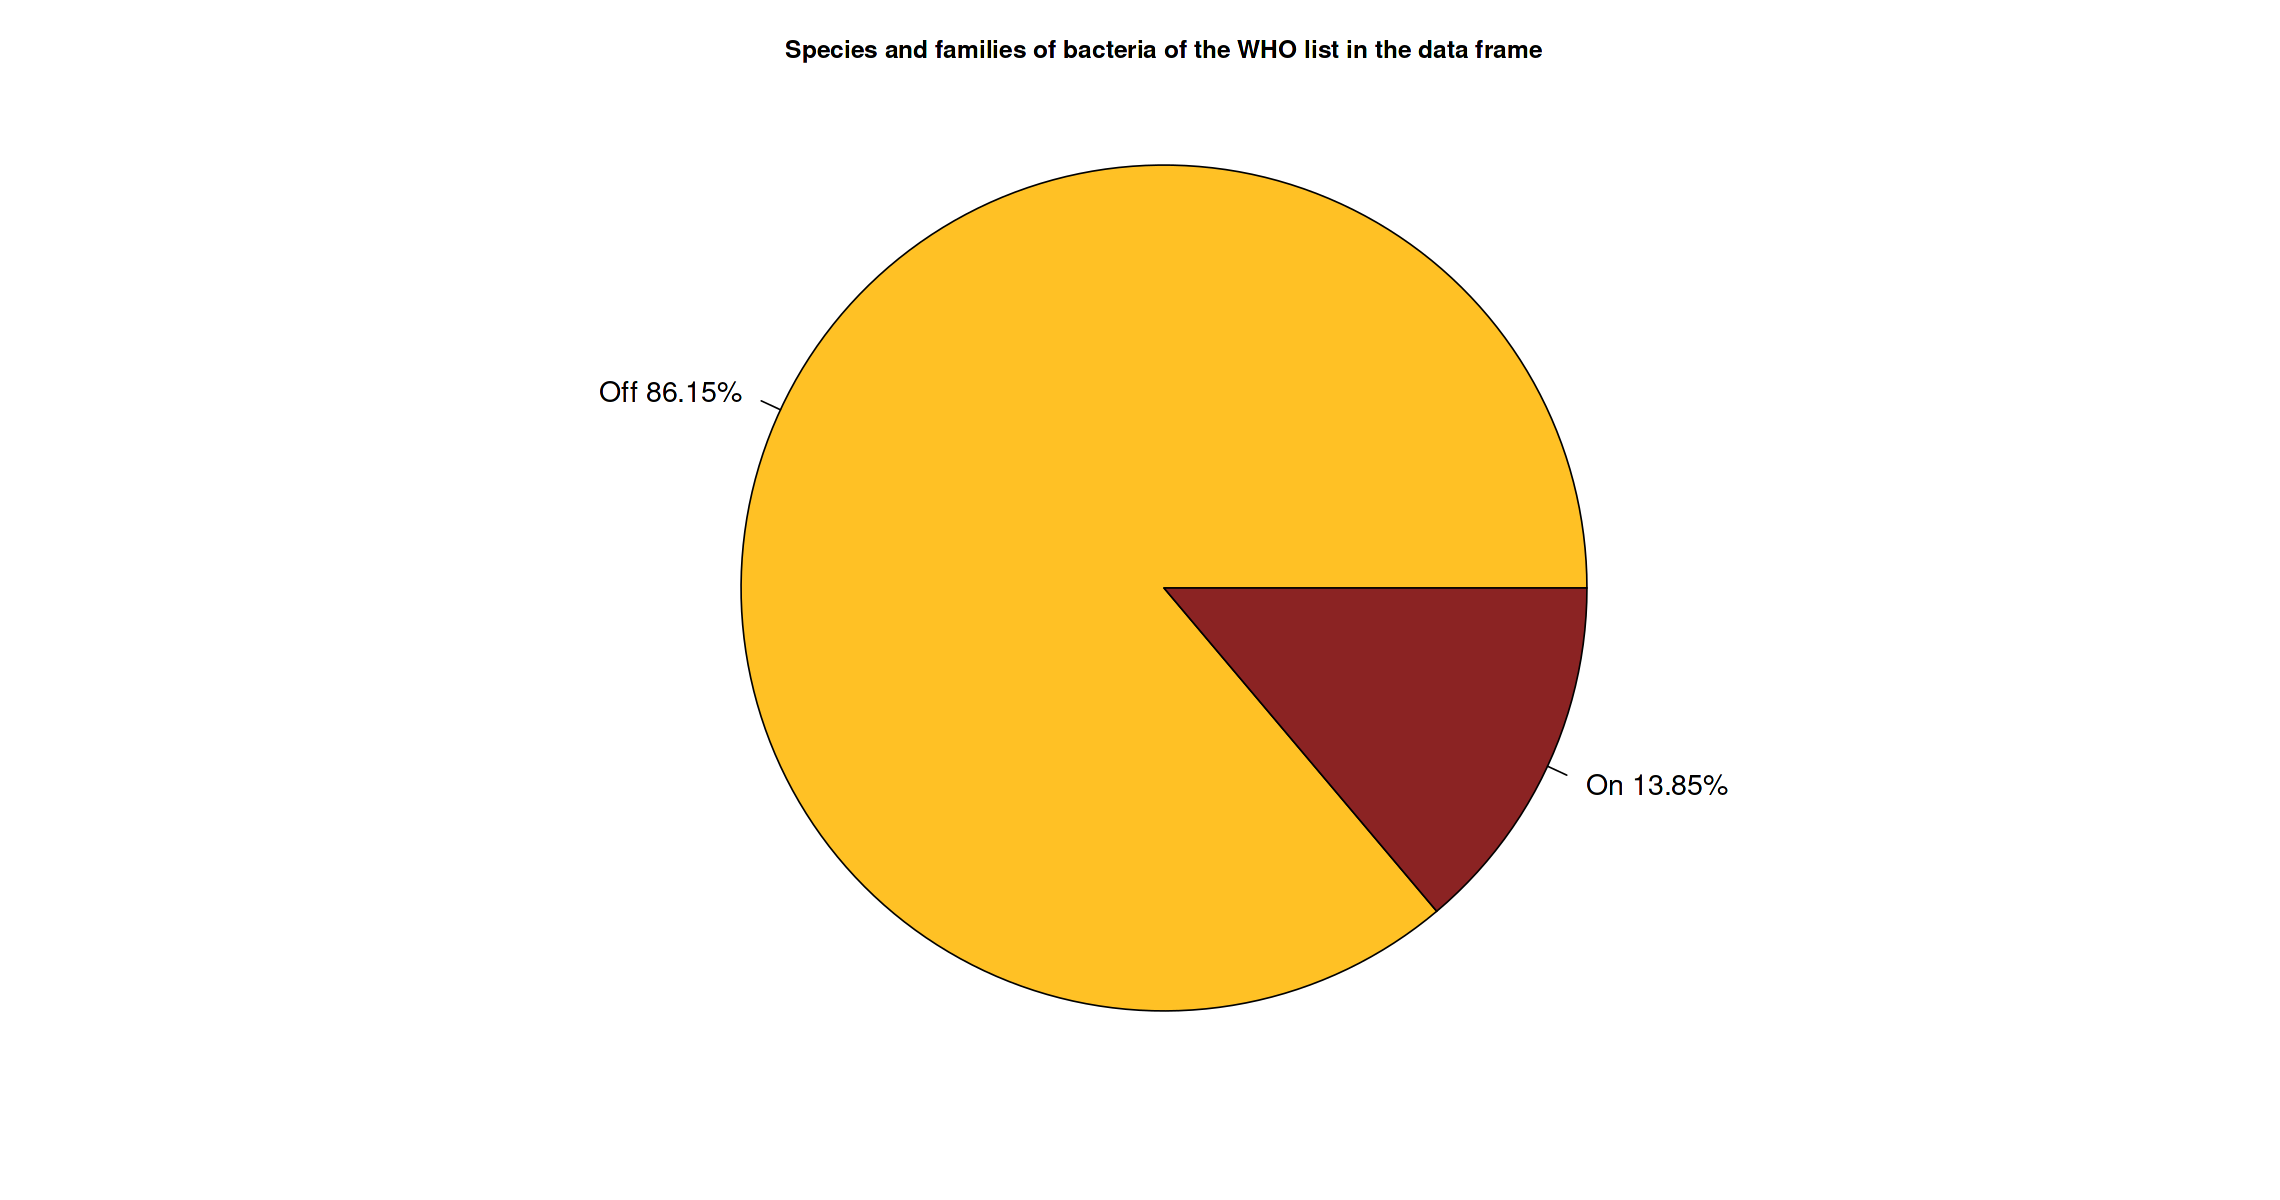

In [23]:
pct1 <- round(who_bacteria_matches_harmful$percent, 2)
lbls1 <- paste(paste(who_bacteria_matches_harmful$who_list, pct1), "%", sep="")
pie(who_bacteria_matches_harmful$percent, labels = lbls1, col = c("goldenrod1", "brown4"),radius = 1,cex = 1.4,
    main = "Species and families of bacteria of the WHO list in the data frame")

Plot with a number of bacteria that are harmful/harmless to humans:

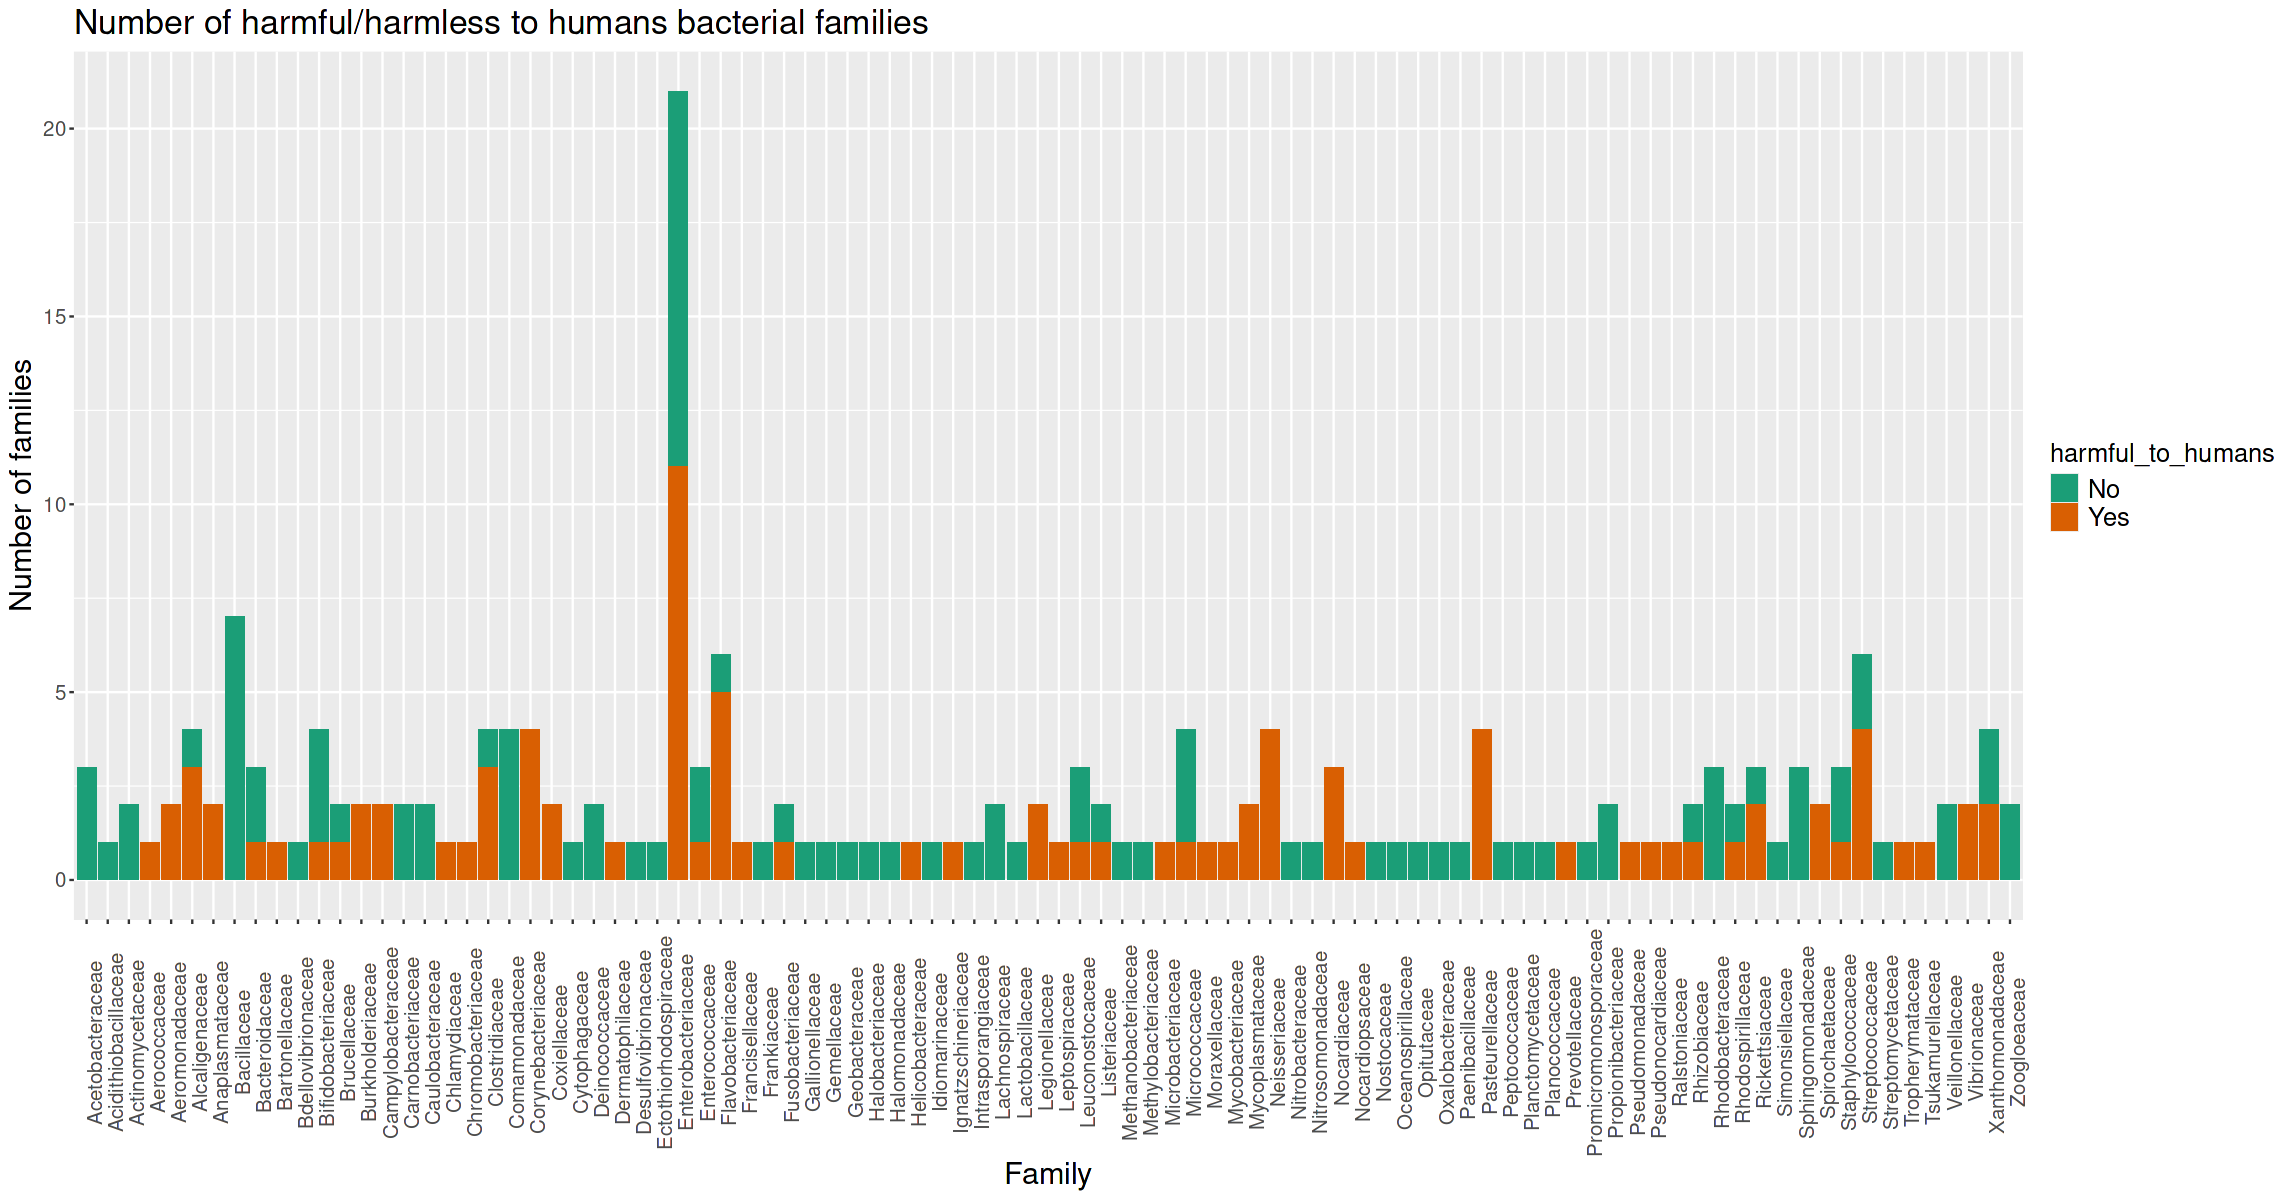

In [24]:
p_family <- 
  ggplot(data = bacteria1) +
  geom_bar(mapping = aes(x = family, fill = harmful_to_humans))+
  labs(title="Number of harmful/harmless to humans bacterial families",
       x = "Family",
       y = "Number of families") +
  scale_fill_brewer(palette = "Dark2")

p_family + theme(axis.text.x = element_text(size=12, angle = 90),
                axis.text.y = element_text(size=12),
                axis.title.x =element_text(size = 18),
                axis.title.y =element_text(size = 18),
                legend.text = element_text(size = 15),
                legend.title = element_text(size = 15),
                plot.title = element_text(size = 20))

Counting how many bacteria are on the WHO list but marked as harmless at the 'bacteria' data frame

In [25]:
who_bacteria_list <- 
  bacteria1 %>% 
  filter(who_list == "On" & harmful_to_humans == "No")
glimpse(who_bacteria_list)

Rows: 10
Columns: 5
$ name              <chr> "Serratia marcescens", "Proteus mirabilis", "Klebsie…
$ family            <chr> "Enterobacteriaceae", "Enterobacteriaceae", "Enterob…
$ where_found       <chr> "Soil, water, intestines", "Intestinal tract", "Inte…
$ harmful_to_humans <chr> "No", "No", "No", "No", "No", "No", "No", "No", "No"…
$ who_list          <chr> "On", "On", "On", "On", "On", "On", "On", "On", "On"…


5.13% of the bacteria are on the WHO list but marked as harmless in the 'bacteria' data frame:

In [26]:
percent_who_on <- round(count(who_bacteria_list)/count(bacteria1)*100, 2)
percent_who_on

n
<dbl>
5.13


This stems from the fact that these bacteria can be harmful and cause various infections in humans, however, immunocompromised people are most vulnerable.

Plot with the number of bacteria that are on/off the WHO list:

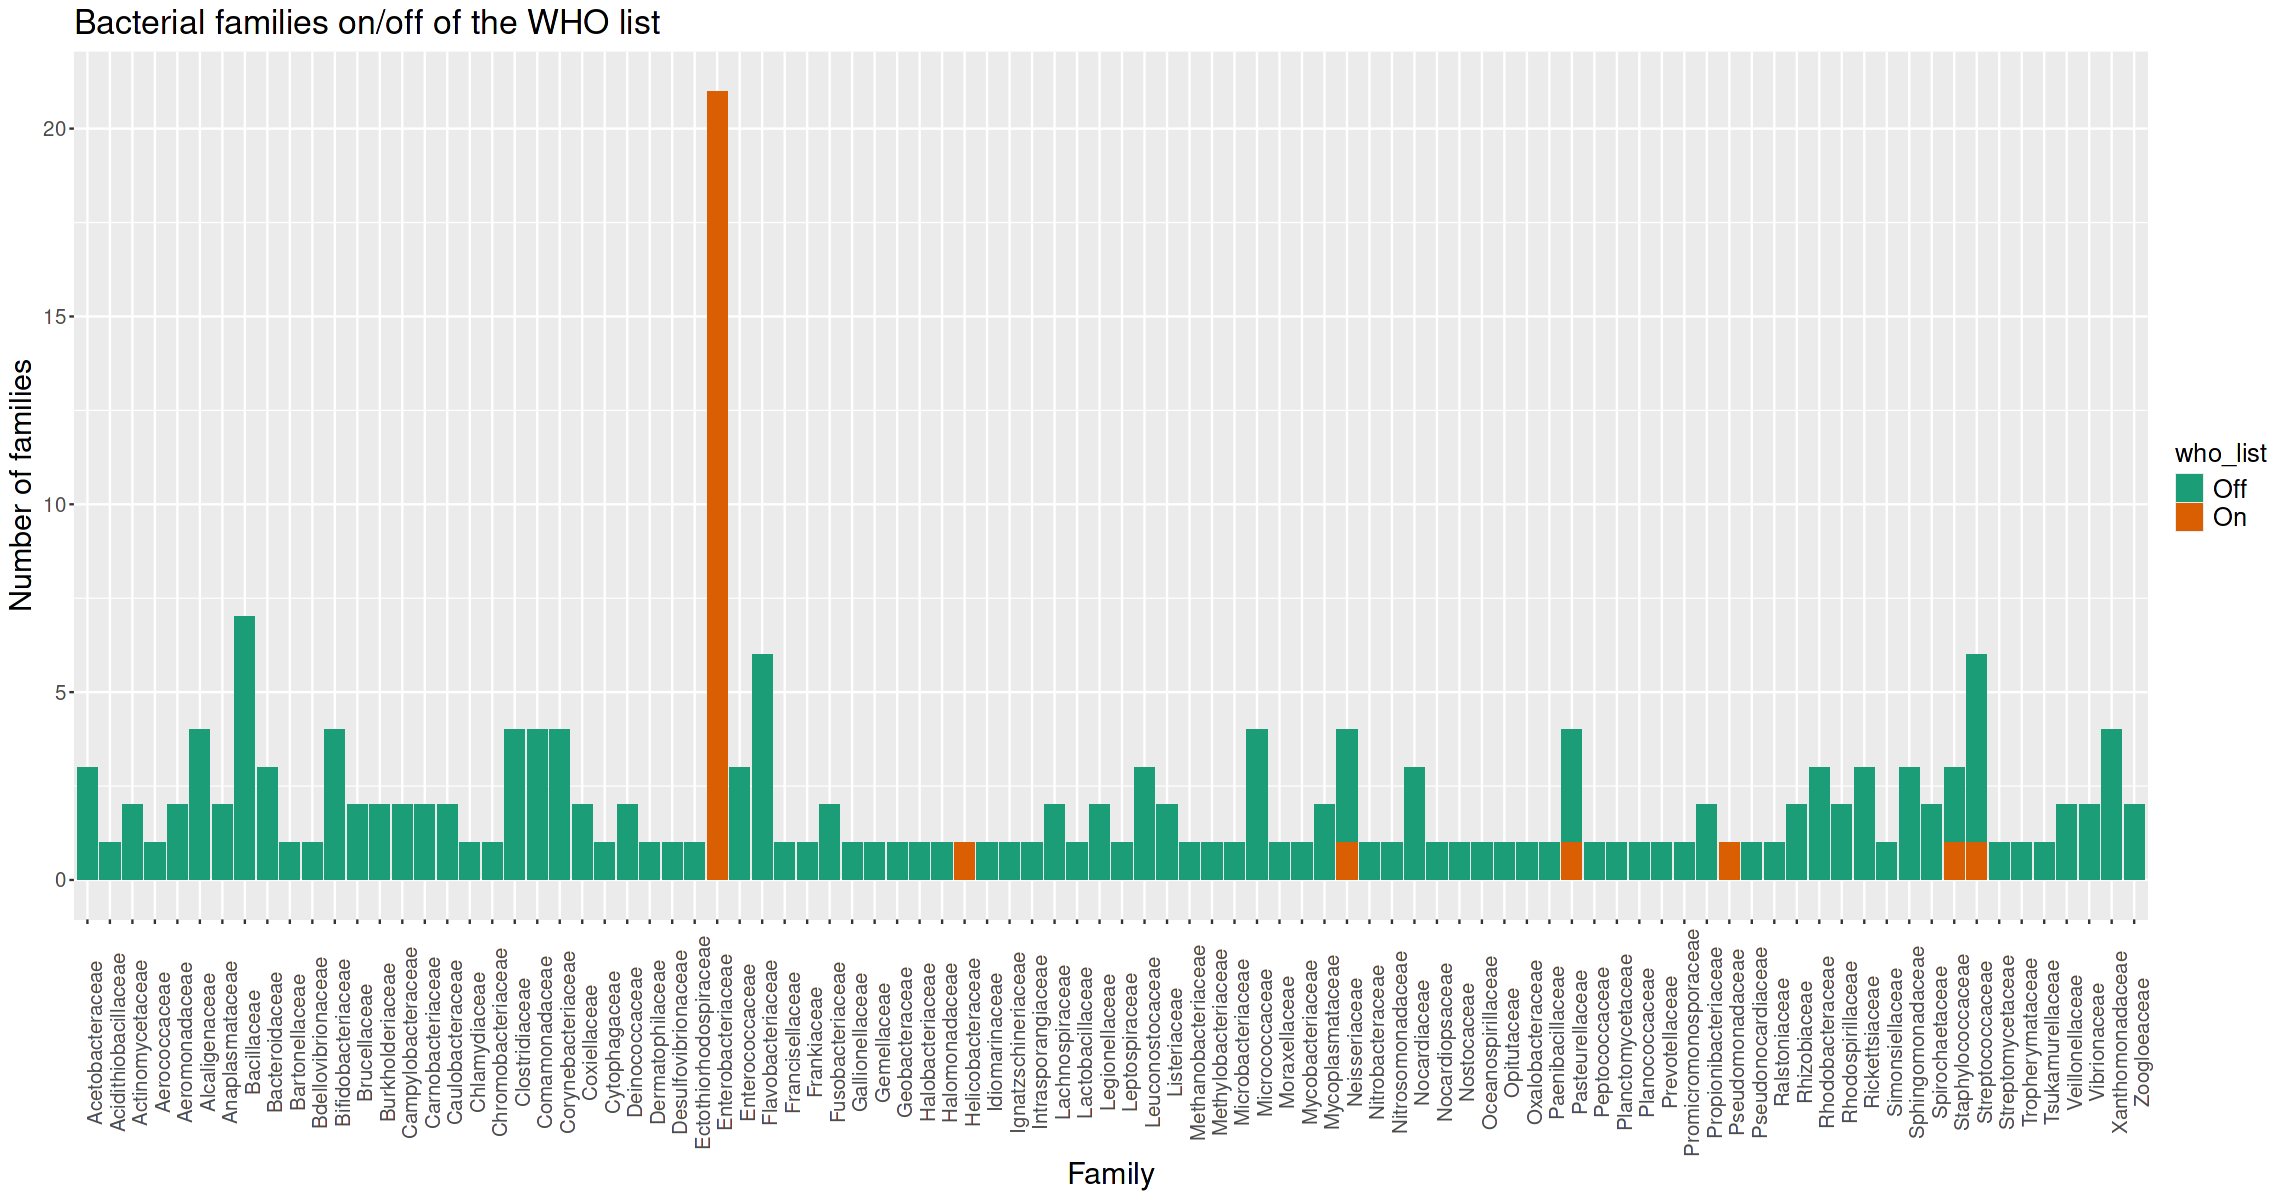

In [27]:
p_who_family <- 
  ggplot(data = bacteria1) +
  geom_bar(mapping = aes(x = family, fill = who_list))+
  labs(title="Bacterial families on/off of the WHO list",
       x = "Family",
       y = "Number of families") +
scale_fill_brewer(palette = "Dark2")

p_who_family + theme(axis.text.x = element_text(size=12, angle = 90),
                axis.text.y = element_text(size=12),
                axis.title.x =element_text(size = 18),
                axis.title.y =element_text(size = 18),
                legend.text = element_text(size = 15),
                legend.title = element_text(size = 15),
                plot.title = element_text(size = 20))

Preparing data for the WORD CLOUD visualization of WHO-listed harmful bacteria species localization from the initial 'bacteria' dataset:

In [28]:
# Function that splits comma-separated values into multiple rows of the 'where_found', remove whitespaces at the beginning of the row and convert to title case

convertion <- function(df) {
  separate_rows(df, where_found, sep = ",", convert = TRUE) %>% 
    mutate_all(function(x)trimws(x)) %>% 
    mutate(where_found = paste0(toupper(substring(where_found, 1, 1)), substring(where_found, 2)))
}


df <- who_bacteria_matches
matches_cloud <- convertion(df)
head(matches_cloud)

name,family,where_found,harmful_to_humans
<chr>,<chr>,<chr>,<chr>
Staphylococcus aureus,Staphylococcaceae,Skin,Yes
Staphylococcus aureus,Staphylococcaceae,Nasal passages,Yes
Streptococcus pneumoniae,Streptococcaceae,Throat,Yes
Streptococcus pneumoniae,Streptococcaceae,Nasal passages,Yes
Pseudomonas aeruginosa,Pseudomonadaceae,Soil,Yes
Pseudomonas aeruginosa,Pseudomonadaceae,Water,Yes


In [29]:
# Using log scaling for the localization frequency counting

wcloud <- as.data.frame(table(matches_cloud$where_found))%>% 
  arrange(desc(Freq)) %>% 
  mutate(ScaledFrequency = log1p(Freq))
head(wcloud)

,Var1,Freq,ScaledFrequency
,<fct>,<int>,<dbl>
1,Intestinal tract,8,2.197225
2,Soil,6,1.945910
3,Water,5,1.791759
4,Human gut,3,1.386294
5,Environment,2,1.098612
6,Intestines,2,1.098612


Word cloud:

In [30]:
wordcloud2(data = wcloud %>% select(Var1, ScaledFrequency), 
           size = 0.5, color = 'random-dark', shape = "circle")

HTML widgets cannot be represented in plain text (need html)

# Summary

1. The most popular locations of the harmful to human bacteria are soil, water and the intestinal tract.
   
3. 13,8% of all the bacteria in the 'bacteria' data frame are on the WHO list.
  
5. 5.13% of the bacteria are on the WHO list of antibiotic-resistant pathogens but marked as harmless at the 'bacteria' data frame
This stems from the fact that these bacteria can be harmful and cause various infections in humans, however, immunocompromised people are most vulnerable.

6. The most common localization of the bacteria species from the WHO list is the intestinal tract.

7. Easy to copy WHO-list bacterial species and families if you want it to check later:

Acinetobacter baumannii, Pseudomonas aeruginosa, Enterococcus faecium, Staphylococcus aureus, Helicobacter pylori, Neisseria gonorrhoeae, Streptococcus pneumoniae, Haemophilus influenzae, Enterobacteriaceae, Campylobacter, Salmonellae, Shigella.

Thank you for reading! Your feedback is valuable for me!